In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_arch

import scipy.stats as slice

!pip install arch

In [17]:
df = pd.read_excel(r'/content/Rice Vietnamese 5%.xlsx')
df


,Date,"Rice, Vietnamese 5%"
0,NaN,($/mt)
1,2010M01,485.28
2,2010M02,421.79
3,2010M03,392.57
4,2010M04,371.17
...,...,...
193,2026M01,351.2
194,2026M02,349.14
195,2026M03,345.78
196,2026M04,352.85


In [18]:
# Làm sạch dữ liệu
df.columns = df.columns.str.strip()
df.columns = ['Date', 'Price']

#Xu ly dinh dang 'YYYYMmm' thanh 'YYYY-MM'
df['Date'] = df['Date'].astype(str).str.replace('M', '-')
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])

#Chuyen doi Price sang kieu float
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df

/tmp/ipykernel_2214/2314151135.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Price'] = pd.to_numeric(df['Price'], errors='coerce')


,Date,Price
1,2010-01-01,485.28
2,2010-02-01,421.79
3,2010-03-01,392.57
4,2010-04-01,371.17
5,2010-05-01,368.82
...,...,...
193,2026-01-01,351.20
194,2026-02-01,349.14
195,2026-03-01,345.78
196,2026-04-01,352.85


In [19]:
#Đặt tần suất dữ liệu thành hàng tháng
df.set_index('Date', inplace=True)
df = df.asfreq('MS')

In [20]:
#Xử lý giá trị khuyết thiếu bằng nội suy tuyến tính
df['Price'] = df['Price'].interpolate(method='linear')
df


,Price
Date,
2010-01-01,485.28
2010-02-01,421.79
2010-03-01,392.57
2010-04-01,371.17
2010-05-01,368.82
...,...
2026-01-01,351.20
2026-02-01,349.14
2026-03-01,345.78


In [21]:
#Tính tỷ suất sinh lợi logarit theo công thức: log(Pt/Pt-1)
df['Log_Returns'] = np.log(df['Price'] / df['Price'].shift(1))
df['Log_Returns'] = df['Log_Returns'].dropna()


In [22]:
print(df)

             Price  Log_Returns
Date                           
2010-01-01  485.28          NaN
2010-02-01  421.79    -0.140218
2010-03-01  392.57    -0.071793
2010-04-01  371.17    -0.056055
2010-05-01  368.82    -0.006351
...            ...          ...
2026-01-01  351.20    -0.002020
2026-02-01  349.14    -0.005883
2026-03-01  345.78    -0.009670
2026-04-01  352.85     0.020240
2026-05-01  376.33     0.064423

[197 rows x 2 columns]


In [23]:
#Cấu hình đồ họa cho scannable trực quan
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.2)
plt.figure(figsize=(12, 5))


<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

In [24]:
#2.1 Kiểm định tính dừng ADF
return_series = df['Log_Returns'].dropna()
adf_result = adfuller(return_series)
print(f'ADF Statistic: {adf_result[0]:.4f}')
print(f'p-value: {adf_result[1]:.4f}')


ADF Statistic: -8.3651
p-value: 0.0000


In [25]:
for key, value in adf_result[4].items():
    print(f'Critical Value ({key}): {value:.4f}')
if adf_result[1] < 0.05:
    print("Kết luận: Dữ liệu là dừng (reject H0)")
else:
    print("Kết luận: Dữ liệu không dừng (fail to reject H0)")

Critical Value (1%): -3.4645
Critical Value (5%): -2.8766
Critical Value (10%): -2.5748
Kết luận: Dữ liệu là dừng (reject H0)


In [26]:
# 2.2 Kiểm định tính đồng nhất ARCH
arch_test = het_arch(return_series)
print(f'ARCH Test Statistic: {arch_test[0]:.4f}')
print(f'p-value: {arch_test[1]:.4f}')

ARCH Test Statistic: 19.8539
p-value: 0.0307


In [27]:
if arch_test[1] < 0.05:
    print("Kết luận: Dữ liệu có tính đồng nhất ARCH (reject H0)")
else:
    print("Kết luận: Dữ liệu không có tính đồng nhất ARCH (fail to reject H0)")

Kết luận: Dữ liệu có tính đồng nhất ARCH (reject H0)


In [28]:
# 2.3 ƯỚC LƯỢNG MÔ HÌNH GARCH(1,1) - GED

#Khởi tạo mô hình GARCH(1,1) với phân phối GED
from arch import arch_model

# Khử trung bình bằng cách trừ mean từ chuỗi log returns
mean_return = return_series.mean()
demeaned_returns = return_series - mean_return

lm_test = het_arch(demeaned_returns)
print(f'ARCH Test Statistic (demeaned): {lm_test[0]:.4f}')
print(f'p-value (demeaned): {lm_test[1]:.4f}')

ARCH Test Statistic (demeaned): 19.4792
p-value (demeaned): 0.0346


In [29]:
if lm_test[1] < 0.05:
    print("Kết luận: Dữ liệu khử trung bình có tính đồng nhất ARCH (reject H0)")
else:
    print("Kết luận: Dữ liệu khử trung bình không có tính đồng nhất ARCH (fail to reject H0)")


Kết luận: Dữ liệu khử trung bình có tính đồng nhất ARCH (reject H0)


In [30]:
# Khởi tạo mô hình GARCH(1,1) với phân phối GED
garch_model = arch_model(demeaned_returns, vol='Garch', p=1, q=1, dist='ged')
garch_fit = garch_model.fit()

print(garch_fit.summary())

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001845. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


Iteration:      1,   Func. Count:      7,   Neg. LLF: 43810.178500786096
Iteration:      2,   Func. Count:     19,   Neg. LLF: 218063.19479652384
Iteration:      3,   Func. Count:     27,   Neg. LLF: -306.4402036429774
Iteration:      4,   Func. Count:     34,   Neg. LLF: -340.40256291526845
Iteration:      5,   Func. Count:     41,   Neg. LLF: -328.3451434597214
Iteration:      6,   Func. Count:     48,   Neg. LLF: -330.84395542766606
Iteration:      7,   Func. Count:     55,   Neg. LLF: -331.0972872660217
Iteration:      8,   Func. Count:     62,   Neg. LLF: -327.29579851953133
Iteration:      9,   Func. Count:     69,   Neg. LLF: -327.5383474861462
Iteration:     10,   Func. Count:     76,   Neg. LLF: -347.7803154395514
Iteration:     11,   Func. Count:     83,   Neg. LLF: -325.21558046578104
Iteration:     12,   Func. Count:     90,   Neg. LLF: 1.1713028481041657e+20
Iteration:     13,   Func. Count:    102,   Neg. LLF: 385340.57192775887
Iteration:     14,   Func. Count:    112,  

In [31]:
# Trích xuất độ biến động dự đoán từ mô hình GARCH
predicted_volatility = garch_fit.conditional_volatility
df['Predicted_Volatility'] = predicted_volatility
# Đổi sang năm
df['Predicted_Volatility'] = df['Predicted_Volatility'] * np.sqrt(12)
print(df[['Log_Returns', 'Predicted_Volatility']].head())


            Log_Returns  Predicted_Volatility
Date                                         
2010-01-01          NaN                   NaN
2010-02-01    -0.140218              0.231022
2010-03-01    -0.071793              0.227492
2010-04-01    -0.056055              0.224062
2010-05-01    -0.006351              0.220730


In [32]:
import numpy as np
import scipy.stats as stats

# Hàm định giá Black-Scholes hiệu chỉnh GARCH

def black_scholes_garch(S, K, T, r, sigma, option_type='call'):

    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = S * stats.norm.cdf(d1) - K * np.exp(-r * T) * stats.norm.cdf(d2)
    elif option_type == 'put':
        price = K * np.exp(-r * T) * stats.norm.cdf(-d2) - S * stats.norm.cdf(-d1)
    else:
        raise ValueError("Loại quyền chọn phải là 'call' hoặc 'put'.")

    return price

In [34]:
# Xuất bảng phí Quyền chọn (Premium) dựa trên độ biến động dự đoán từ mô hình GARCH

latest_date = df.index[-1]
latest_price = df['Price'].iloc[-1]
latest_volatility = df['Predicted_Volatility'].iloc[-1]

# Giả định các tham số khác cho mô hình Black-Scholes
X_atm = latest_price  # Giá thực hiện bằng giá hiện tại (ATM)
r = 0.05  # Lãi suất phi rủi ro (5%)

periods = {'1-month': 1/12, '3-month': 3/12, '6-month': 6/12}
premium_table = []

for period, time in periods.items():
    call_premium = black_scholes_garch(X_atm, X_atm, time, r, latest_volatility, option_type='call')
    put_premium = black_scholes_garch(X_atm, X_atm, time, r, latest_volatility, option_type='put')
    premium_table.append({'Period': period, 'Call Premium': call_premium, 'Put Premium': put_premium})

df_premium = pd.DataFrame(premium_table)
print(df_premium)



    Period  Call Premium  Put Premium
0  1-month      6.276456     4.711677
1  3-month     11.935501     7.260655
2  6-month     18.390234     9.098613


In [35]:
# So sánh với mô hình tĩnh
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel

T_30 = 30/365
r_baseline = 0.05  # Lãi suất phi rủi ro (5%)

# Tính độ biến động tĩnh hằng số làm hệ quy chiếu
static_volatility = df['Log_Returns'].std() * np.sqrt(12)

garch_call_prices = []
static_call_prices = []

for i in range(len(df)):
    S = df['Price'].iloc[i]
    sigma_garch = df['Predicted_Volatility'].iloc[i]

    garch_call_price = black_scholes_garch(S, S, T_30, r_baseline, sigma_garch, option_type='call')
    static_call_price = black_scholes_garch(S, S, T_30, r_baseline, static_volatility, option_type='call')

    garch_call_prices.append(garch_call_price)
    static_call_prices.append(static_call_price)

df['GARCH_Call_Price'] = garch_call_prices
df['Static_Call_Price'] = static_call_prices


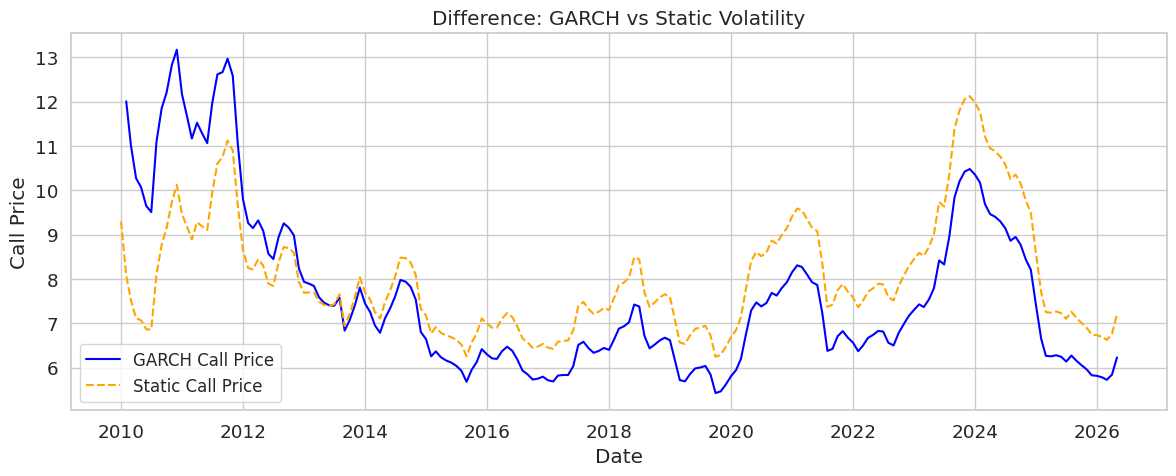

In [36]:
# Trực quan hóa sự khác biệt giữa giá quyền chọn call dựa trên độ biến động GARCH và độ biến động tĩnh hằng số

plt.figure(figsize=(12, 5))
plt.plot(df.index, df['GARCH_Call_Price'], label='GARCH Call Price', color='blue')
plt.plot(df.index, df['Static_Call_Price'], label='Static Call Price', color='orange', linestyle='--')
plt.title('Difference: GARCH vs Static Volatility')
plt.xlabel('Date')
plt.ylabel('Call Price')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()